In [1]:
import pandas as pd

df = pd.read_csv('G:\processed_datasetAfterKNN.csv')
print(df.head())

   Destination Port  Flow Duration  Flow Bytes/s  Flow Packets/s  \
0              80.0        38308.0  3.132505e+02       52.208416   
1             389.0          479.0  1.039666e+06    33402.922760   
2              88.0         1095.0  5.753425e+06    14611.872150   
3             389.0        15206.0  6.650007e+05     1907.141918   
4              88.0         1092.0  5.771062e+06    13736.263740   

   Average Packet Size  Fwd Header Length.1  Subflow Fwd Bytes  \
0             9.000000                 20.0                6.0   
1            31.125000                368.0              172.0   
2           393.750000                336.0             3150.0   
3           348.689655                560.0             3452.0   
4           420.133333                304.0             3150.0   

   Subflow Bwd Bytes  Init_Win_bytes_forward  Init_Win_bytes_backward   Label  \
0                6.0                   255.0                    946.0  BENIGN   
1              326.0            

C:\Users\DPQUAI250139\AppData\Local\Temp\ipykernel_48132\82663605.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time'])


Test set size: 566148 rows


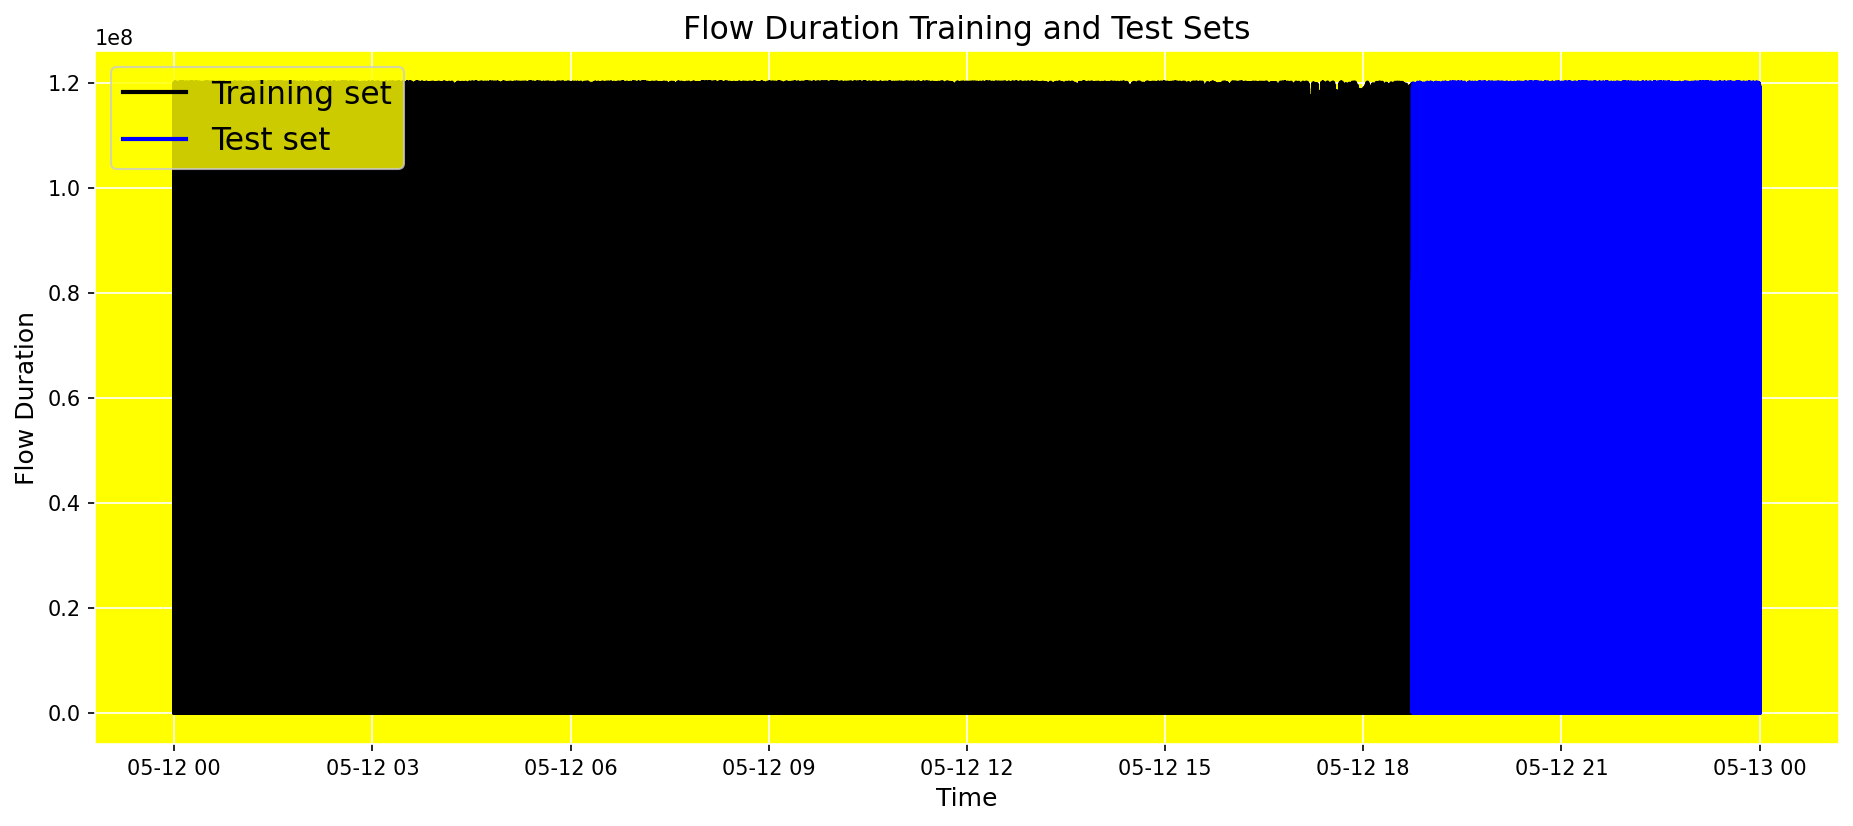

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense
from sklearn.metrics import mean_absolute_percentage_error

# Convert 'Time' column to datetime objects and sort for chronological order
df['Time'] = pd.to_datetime(df['Time'])
df = df.sort_values(by='Time').reset_index(drop=True)

target_col = 'Flow Duration' # Assuming 'Flow Duration' as the target for prediction

# Calculate test_size (20% of the data for testing)
test_size = int(len(df) * 0.2)

# Ensure test_size is at least window_size + 1
window_size = 60 # From the example
if test_size < window_size + 1:
    test_size = window_size + 1

print(f"Test set size: {test_size} rows")

# Plotting Training and Test Sets (Adjusted for generic data and 'Time' column)
plt.figure(figsize=(15, 6), dpi=150)
plt.rcParams['axes.facecolor'] = 'yellow'
plt.rc('axes',edgecolor='white')
plt.plot(df['Time'][:-test_size], df[target_col][:-test_size], color='black', lw=2)
plt.plot(df['Time'][-test_size:], df[target_col][-test_size:], color='blue', lw=2)
plt.title(f'{target_col} Training and Test Sets', fontsize=15)
plt.xlabel('Time', fontsize=12)
plt.ylabel(target_col, fontsize=12)
plt.legend(['Training set', 'Test set'], loc='upper left', prop={'size': 15})
plt.grid(color='white')
plt.show()

In [3]:
scaler = MinMaxScaler()
scaler.fit(df[target_col].values.reshape(-1,1))

MinMaxScaler()

In [4]:
window_size = 60

# Training Set
train_data = df[target_col][:-test_size]
train_data = scaler.transform(train_data.values.reshape(-1,1))
X_train = []
y_train = []

for i in range(window_size, len(train_data)):
    X_train.append(train_data[i-window_size:i, 0])
    y_train.append(train_data[i, 0])

# Test Set
test_data = df[target_col][-test_size-window_size:] # Ensure enough data for sliding window
test_data = scaler.transform(test_data.values.reshape(-1,1))
X_test = []
y_test = []

for i in range(window_size, len(test_data)):
    X_test.append(test_data[i-window_size:i, 0])
    y_test.append(test_data[i, 0])

In [5]:
X_train = np.array(X_train)
X_test  = np.array(X_test)
y_train = np.array(y_train)
y_test  = np.array(y_test)

X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test  = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
y_train = np.reshape(y_train, (-1,1))
y_test  = np.reshape(y_test, (-1,1))

print('X_train Shape: ', X_train.shape)
print('y_train Shape: ', y_train.shape)
print('X_test Shape:  ', X_test.shape)
print('y_test Shape:  ', y_test.shape)

X_train Shape:  (2264535, 60, 1)
y_train Shape:  (2264535, 1)
X_test Shape:   (566148, 60, 1)
y_test Shape:   (566148, 1)


In [6]:
# Model Definition
def define_model():
    input1 = Input(shape=(window_size,1))
    x = LSTM(units = 64, return_sequences=True)(input1)  
    x = Dropout(0.2)(x)
    x = LSTM(units = 64, return_sequences=True)(x)
    x = Dropout(0.2)(x)
    x = LSTM(units = 64)(x)
    x = Dropout(0.2)(x)
    x = Dense(32, activation='softmax')(x)
    dnn_output = Dense(1)(x)

    model = Model(inputs=input1, outputs=[dnn_output])
    model.compile(loss='mean_squared_error', optimizer='Nadam')
    model.summary()
    
    return model

# Model Training
model = define_model()
history = model.fit(X_train, y_train, epochs=25, batch_size=32, validation_split=0.1, verbose=1)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 60, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,057 (332.25 KB)

 Trainable params: 85,057 (332.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
63691/63691 ━━━━━━━━━━━━━━━━━━━━ 1464s 23ms/step - loss: 0.0394 - val_loss: 0.0313
Epoch 2/25
63691/63691 ━━━━━━━━━━━━━━━━━━━━ 1362s 21ms/step - loss: 0.0339 - val_loss: 0.0271
Epoch 3/25
63691/63691 ━━━━━━━━━━━━━━━━━━━━ 1794s 28ms/step - loss: 0.0330 - val_loss: 0.0264
Epoch 4/25
63691/63691 ━━━━━━━━━━━━━━━━━━━━ 2738s 43ms/step - loss: 0.0327 - val_loss: 0.0249
Epoch 5/25
63691/63691 ━━━━━━━━━━━━━━━━━━━━ 2735s 43ms/step - loss: 0.0324 - val_loss: 0.0248
Epoch 6/25
63691/63691 ━━━━━━━━━━━━━━━━━━━━ 2763s 43ms/step - loss: 0.0323 - val_loss: 0.0254
Epoch 7/25
63691/63691 ━━━━━━━━━━━━━━━━━━━━ 2752s 43ms/step - loss: 0.0321 - val_loss: 0.0247
Epoch 8/25
63691/63691 ━━━━━━━━━━━━━━━━━━━━ 2737s 43ms/step - loss: 0.0320 - val_loss: 0.0246
Epoch 9/25
63691/63691 ━━━━━━━━━━━━━━━━━━━━ 2785s 43ms/step - loss: 0.0319 - val_loss: 0.0225
Epoch 10/25
63691/63691 ━━━━━━━━━━━━━━━━━━━━ 2762s 43ms/step - loss: 0.0319 - val_loss: 0.0227
Epoch 11/25
63691/63691 ━━━━━━━━━━━━━━━━━━━━ 2736s 43ms/ste

In [7]:
result = model.evaluate(X_test, y_test)
y_pred = model.predict(X_test) 
MAPE = mean_absolute_percentage_error(y_test, y_pred)
Accuracy = 1 - MAPE
print("Test Loss:", result)
print("Test MAPE:", MAPE)
print("Test Accuracy:", Accuracy)

17693/17693 ━━━━━━━━━━━━━━━━━━━━ 155s 9ms/step - loss: 0.0514
17693/17693 ━━━━━━━━━━━━━━━━━━━━ 146s 8ms/step
Test Loss: 0.05138062685728073
Test MAPE: 54246.65735815268
Test Accuracy: -54245.65735815268


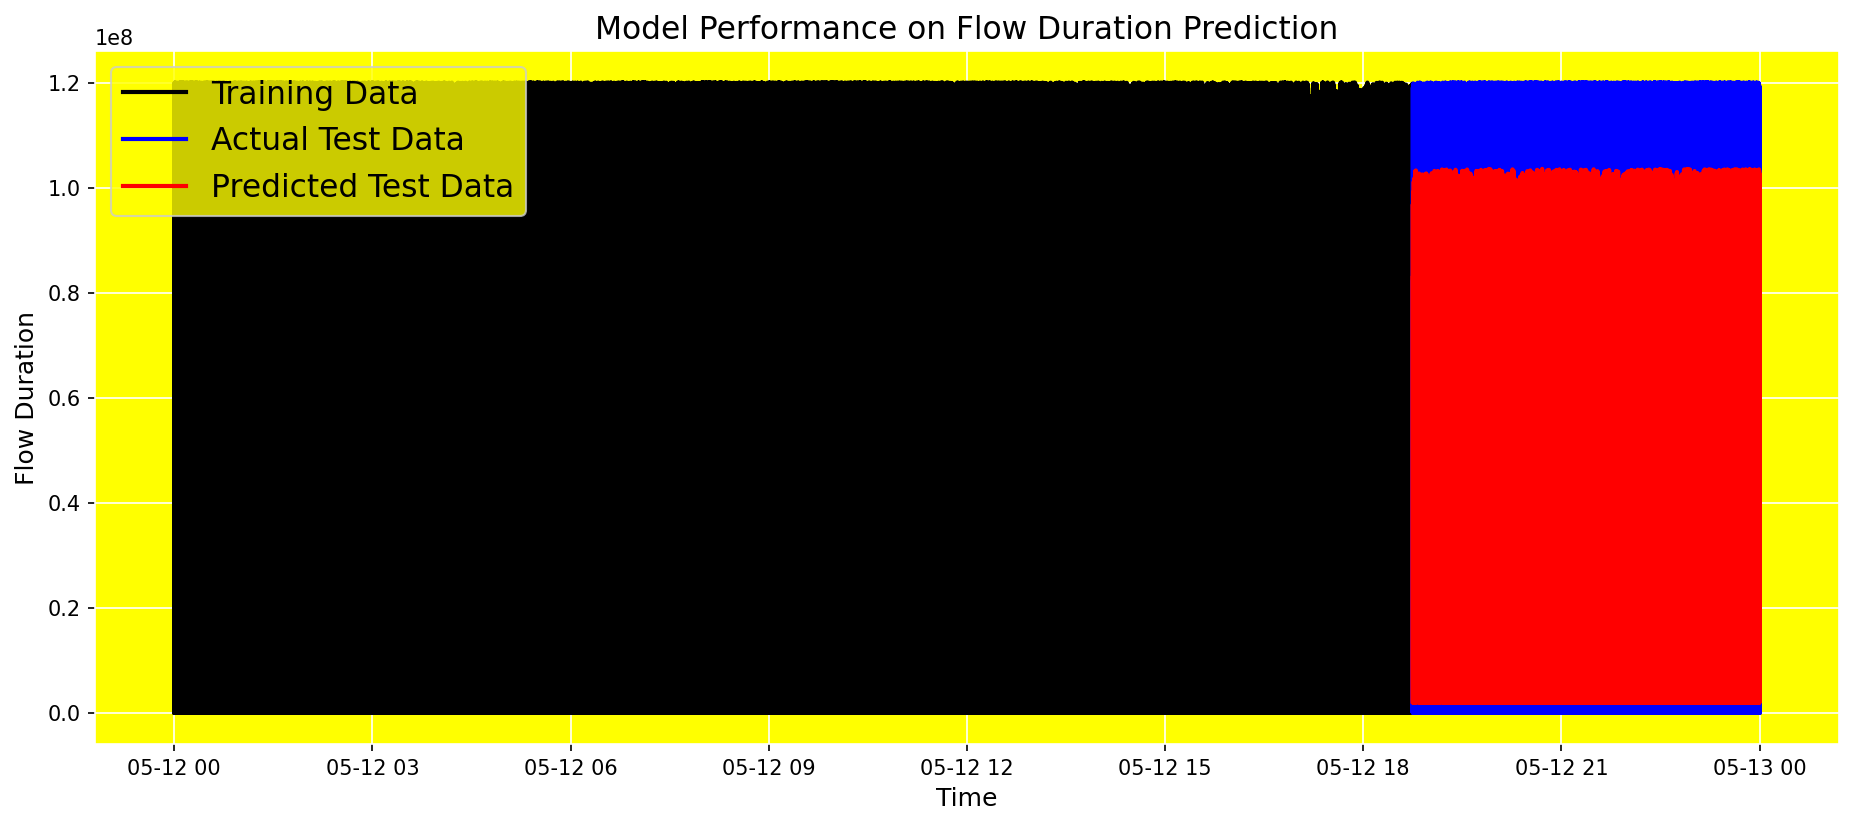

In [8]:
y_test_true = scaler.inverse_transform(y_test)
y_test_pred = scaler.inverse_transform(y_pred)

# Investigating the closeness of the predicted values to the actual values
plt.figure(figsize=(15, 6), dpi=150)
plt.rcParams['axes.facecolor'] = 'yellow'
plt.rc('axes',edgecolor='white')
plt.plot(df['Time'].iloc[:-test_size], scaler.inverse_transform(train_data), color='black', lw=2)
plt.plot(df['Time'].iloc[-test_size:], y_test_true, color='blue', lw=2)
plt.plot(df['Time'].iloc[-test_size:], y_test_pred, color='red', lw=2)
plt.title(f'Model Performance on {target_col} Prediction', fontsize=15)
plt.xlabel('Time', fontsize=12)
plt.ylabel(target_col, fontsize=12)
plt.legend(['Training Data', 'Actual Test Data', 'Predicted Test Data'], loc='upper left', prop={'size': 15})
plt.grid(color='white')
plt.show()

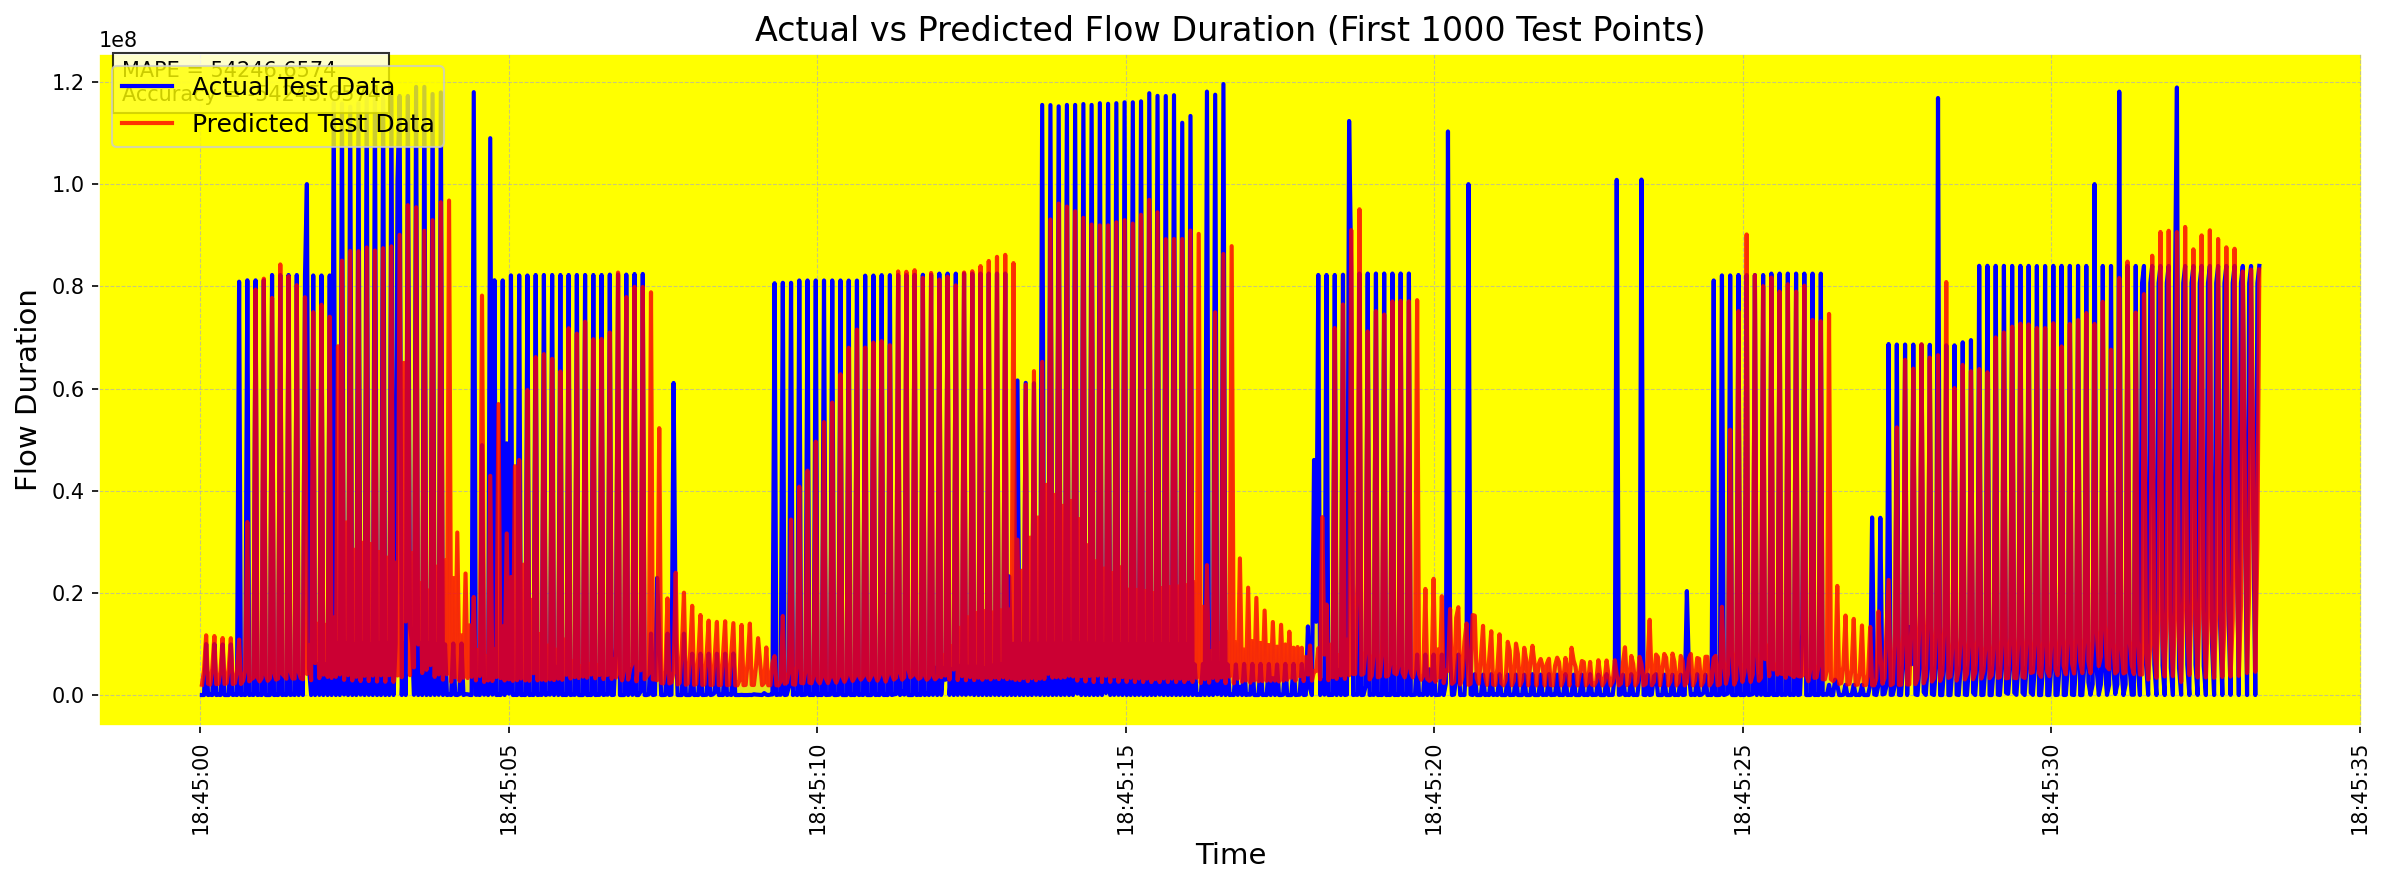

In [9]:
# Plot a smaller subset of the test period to make the final result clearer
plot_n = min(1000, len(y_test_true))
time_test = df['Time'].iloc[-test_size:].reset_index(drop=True)
time_sample = time_test.iloc[:plot_n]
actual_sample = y_test_true[:plot_n].flatten()
pred_sample = y_test_pred[:plot_n].flatten()

plt.figure(figsize=(16, 6), dpi=150)
plt.plot(time_sample, actual_sample, label='Actual Test Data', color='blue', linewidth=2)
plt.plot(time_sample, pred_sample, label='Predicted Test Data', color='red', linewidth=2, alpha=0.8)
plt.fill_between(time_sample, actual_sample, pred_sample, color='gray', alpha=0.2)
plt.title(f'Actual vs Predicted {target_col} (First {plot_n} Test Points)', fontsize=16)
plt.xlabel('Time', fontsize=14)
plt.ylabel(target_col, fontsize=14)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.xticks(rotation=90)
plt.text(0.01, 0.93, f'MAPE = {MAPE:.4f}\nAccuracy = {Accuracy:.4f}', transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))
plt.tight_layout()
plt.show()